# Proyecto BioGen — Análisis Genómico

Este notebook procesa archivos FASTA para extraer features básicos (longitud y contenido GC), realiza análisis exploratorio y entrena un modelo de regresión lineal simple para predecir el contenido GC en función de la longitud.

Instrucciones: editar la celda de parámetros, ejecutar en orden y revisar las salidas en `resultados/`.

In [ ]:
# Parámetros (editar según sea necesario)
folder_path = '../data/raw/'
output_path = '../data/processed/features_genes.csv'
resultados_path = '../resultados'
graficos_path = '../graficos'
run_model = True
long_nueva = 5000
sample_limit = None  # None para procesar todos los archivos

import os
os.makedirs(os.path.dirname(output_path), exist_ok=True)
os.makedirs(resultados_path, exist_ok=True)
os.makedirs(graficos_path, exist_ok=True)

print('Parámetros cargados:')
print(f'  folder_path: {folder_path}')
print(f'  output_path: {output_path}')
print(f'  resultados_path: {resultados_path}')
print(f'  graficos_path: {graficos_path}')
print(f'  run_model: {run_model}')

In [12]:
# 2: Instalación de librerias (Solo ejecutar la primera vez o en un PC nuevo)
# %pip install pandas seaborn matplotlib biopython scikit-learn

In [13]:
# 3: Importacion de librerias y procesamiento bioinformatico.

from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Procesar archivos FASTA en la carpeta raw
datos_genes = []
print('🧬 Procesando secuencias...')
n = 0
for archivo in os.listdir(folder_path):
    if sample_limit is not None and n >= sample_limit:
        break
    if archivo.endswith('.fasta') or archivo.endswith('.fa'):
        ruta_completa = os.path.join(folder_path, archivo)
        for record in SeqIO.parse(ruta_completa, 'fasta'):
            longitud = len(record.seq)
            # gc_fraction devuelve un valor entre 0 y 1, lo pasamos a porcentaje
            gc = gc_fraction(record.seq) * 100
            datos_genes.append({'id': record.id, 'longitud': longitud, 'contenido_gc': gc})
            n += 1

# Crear DataFrame y exportar
_df_procesado = pd.DataFrame(datos_genes)
os.makedirs(os.path.dirname(output_path), exist_ok=True)
_df_procesado.to_csv(output_path, index=False)
print(f'✅ procesamiento bioinformatico completado. Archivo guardado en: {output_path}')
display(_df_procesado)

🧬 Procesando secuencias...


✅ procesamiento bioinformatico completado. Archivo guardado en: ../data/processed/features_genes.csv


,id,longitud,contenido_gc
0,NM_000041.4,1166,69.039451
1,NM_000546.6,2512,53.383758
2,NM_001301717.2,2191,54.769512
3,NM_007294.4,7088,41.774831


✅ Gráfico guardado en la carpeta graficos/
✅ Matriz de correlación guardada en resultados/


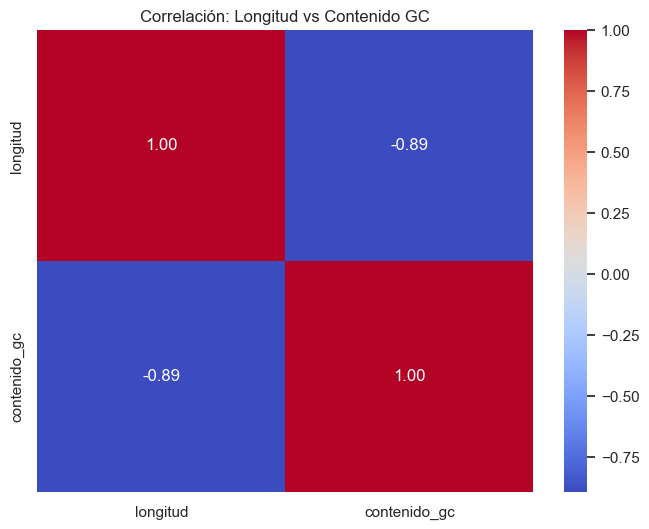

In [14]:
# 4 Carga de datos, graficación y guardado
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv(output_path)

# Configurar el estilo visual
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 6))

# Crear el Heatmap de Correlación
corr = df[['longitud', 'contenido_gc']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación: Longitud vs Contenido GC')

# Guardar gráfico en graficos/
os.makedirs(graficos_path, exist_ok=True)
plt.savefig(os.path.join(graficos_path, 'heatmap_correlacion.png'), dpi=300, bbox_inches='tight')
print('✅ Gráfico guardado en la carpeta graficos/')

# Guardar matriz de correlación
os.makedirs(resultados_path, exist_ok=True)
corr.to_csv(os.path.join(resultados_path, 'matriz_correlacion.csv'))
print('✅ Matriz de correlación guardada en resultados/')

plt.show()

In [15]:
# 5: Inteligencia Artificial - Regresión Lineal

import logging
from sklearn.linear_model import LinearRegression
import numpy as np
import os

# 1. Configurar el logger
log_path = os.path.join(resultados_path, 'entrenamiento_ia.log')
logging.basicConfig(
    filename=log_path,
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='a' # 'a' para añadir (append) al historial existente
)

logging.info('--- Iniciando entrenamiento del modelo de IA ---')

# 2. Preparar los datos
X = df[['longitud']].values
y = df['contenido_gc'].values

# 3. Entrenar el modelo
modelo = LinearRegression()
modelo.fit(X, y)
r2 = modelo.score(X, y)

logging.info(f"Modelo entrenado. Precisión R2: {r2:.4f}")

# 4. Predicción
prediccion = modelo.predict([[long_nueva]])

logging.info(f"Predicción realizada para {long_nueva} bp: {prediccion[0]:.2f}% GC")

print(f"✅ Proceso finalizado. Logs guardados en {log_path}")
print(f"R²: {r2:.4f} | Predicción ({long_nueva}bp): {prediccion[0]:.2f}%")

✅ Proceso finalizado. Logs guardados en ../resultados\entrenamiento_ia.log
R²: 0.7954 | Predicción (5000bp): 48.07%


### Interpretación de Resultados
El análisis de correlación de Pearson arrojó un valor de **-0.89** entre la longitud de la secuencia y el contenido de GC.

**Conclusiones clave:**
1. **Correlación Negativa Fuerte:** Existe una relación inversa casi lineal. A medida que aumenta la longitud del gen, el contenido de GC disminuye significativamente.
2. **Estabilidad Térmica:** Los genes más cortos (como APOE) tienen un GC más alto, lo que sugiere una estructura más estable frente a la desnaturalización térmica.
3. **Validación con Machine Learning:** Debido a la alta correlación, se entrenó un modelo de Regresión Lineal que obtuvo una precisión de $R^2 = 0.7954$. Esto confirma que el 79.5% de la variación en el contenido de GC puede ser explicada únicamente por la longitud del gen

### Capacidad Predictiva:

El modelo permite realizar inferencias sobre nuevas secuencias. Por ejemplo, para un gen teórico de 5000 bp, la IA predice un contenido de GC de 48.07%, siguiendo la tendencia decreciente identificada.

### Significado biologico: 

Este fenómeno podría estar relacionado con la eficiencia energética y la estabilidad estructural en genes de gran tamaño, donde una menor densidad de enlaces triples (G-C) podría facilitar procesos de transcripción más largos o responder a presiones evolutivas específicas.